In [4]:
from pystac_client import Client
import planetary_computer
import rioxarray
import numpy as np
import matplotlib.pyplot as plt

In [5]:


# ------------------------------
# CONNECT TO SATELLITE CATALOGUE
# ------------------------------

catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

In [10]:
bbox = [
    152.85,   # west
    -27.60,   # south
    152.97,   # east
    -27.50    # north
]

print("Bounding box:", bbox)

Bounding box: [152.85, -27.6, 152.97, -27.5]


In [11]:
date_range = "2025-08-01/2025-09-30"

print("Searching:", date_range)

Searching: 2025-08-01/2025-09-30


In [12]:
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=date_range,
    query={
        "eo:cloud_cover": {
            "lt": 20
        }
    }
)

items = list(search.items())

print("Scenes found:", len(items))

Scenes found: 16


In [13]:
for i, item_result in enumerate(items):
    print(
        i,
        item_result.datetime,
        "Cloud:",
        item_result.properties.get("eo:cloud_cover")
    )

0 2025-09-25 00:02:19.024000+00:00 Cloud: 18.141171
1 2025-09-22 00:03:21.024000+00:00 Cloud: 0.494826
2 2025-09-21 23:52:29.024000+00:00 Cloud: 0.431778
3 2025-09-15 00:02:19.024000+00:00 Cloud: 6.759509
4 2025-09-11 23:52:29.024000+00:00 Cloud: 0.026716
5 2025-09-05 00:02:19.024000+00:00 Cloud: 5.568233
6 2025-09-02 00:03:21.024000+00:00 Cloud: 9.27202
7 2025-09-01 23:52:29.024000+00:00 Cloud: 4.811268
8 2025-08-31 00:03:01.025000+00:00 Cloud: 0.01074
9 2025-08-29 23:53:41.024000+00:00 Cloud: 1.350025
10 2025-08-27 23:53:01.025000+00:00 Cloud: 0.05565
11 2025-08-22 23:52:29.024000+00:00 Cloud: 0.019515
12 2025-08-17 23:53:01.025000+00:00 Cloud: 1.868625
13 2025-08-16 00:02:29.024000+00:00 Cloud: 0.05781
14 2025-08-09 23:53:41.024000+00:00 Cloud: 7.993864
15 2025-08-06 00:02:19.024000+00:00 Cloud: 0.054758


In [15]:
if len(items) == 0:
    raise ValueError("No Sentinel-2 scenes found")

item = min(
    items,
    key=lambda x: x.properties.get(
        "eo:cloud_cover",
        100
    )
)

print("Selected scene")
print("ID:", item.id)
print("Date:", item.datetime)
print("Cloud cover:", item.properties.get("eo:cloud_cover"))

Selected scene
ID: S2C_MSIL2A_20250831T000301_R030_T56JMQ_20250831T023314
Date: 2025-08-31 00:03:01.025000+00:00
Cloud cover: 0.01074


In [16]:
print(item.assets.keys())

dict_keys(['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A', 'SCL', 'WVP', 'visual', 'safe-manifest', 'granule-metadata', 'inspire-metadata', 'product-metadata', 'datastrip-metadata', 'tilejson', 'rendered_preview'])


In [17]:
def load_band(item, band_name, bbox):
    band = rioxarray.open_rasterio(
        item.assets[band_name].href,
        masked=True
    ).squeeze()

    band = band.rio.clip_box(
        minx=bbox[0],
        miny=bbox[1],
        maxx=bbox[2],
        maxy=bbox[3],
        crs="EPSG:4326"
    )

    return band

In [18]:
blue = load_band(item, "B02", bbox)
green = load_band(item, "B03", bbox)
red = load_band(item, "B04", bbox)
nir = load_band(item, "B08", bbox)

In [19]:
print("Blue:", blue.shape)
print("Green:", green.shape)
print("Red:", red.shape)
print("NIR:", nir.shape)

Blue: (1110, 1186)
Green: (1110, 1186)
Red: (1110, 1186)
NIR: (1110, 1186)


In [20]:
print("CRS:", red.rio.crs)
print("Resolution:", red.rio.resolution())
print("Bounds:", red.rio.bounds())
print("Shape:", red.shape)

CRS: EPSG:32756
Resolution: (10.0, -10.0)
Bounds: (485180.0, 6947090.0, 497040.0, 6958190.0)
Shape: (1110, 1186)


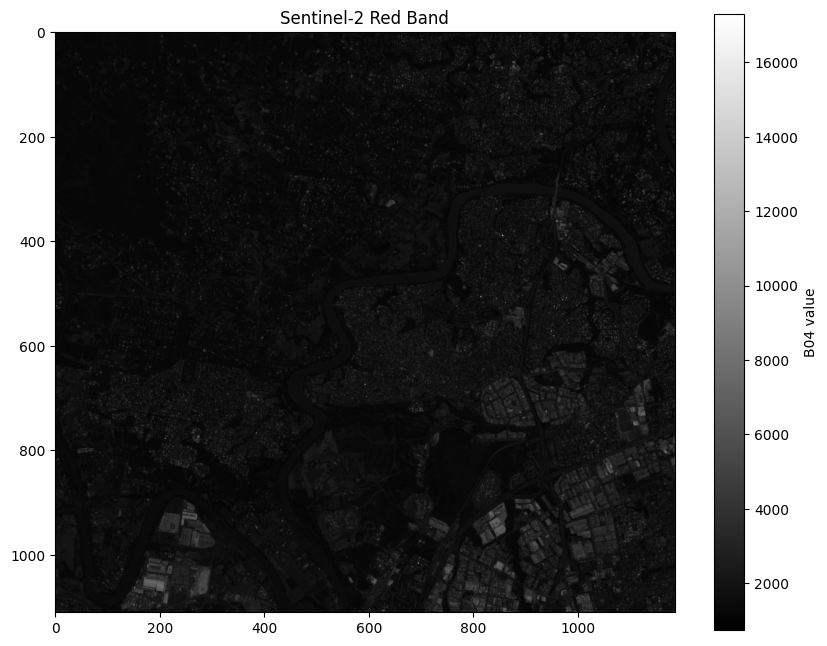

In [25]:
plt.figure(figsize=(10, 8))

plt.imshow(
    red.values,
    cmap="gray"
)

plt.colorbar(
    label="B04 value"
)

plt.title("Sentinel-2 Red Band")

plt.show()

In [26]:
def stretch_band(band):
    low = np.nanpercentile(band, 2)
    high = np.nanpercentile(band, 98)

    stretched = (
        band - low
    ) / (
        high - low
    )

    return np.clip(
        stretched,
        0,
        1
    )

In [27]:
rgb = np.dstack([
    stretch_band(red.values),
    stretch_band(green.values),
    stretch_band(blue.values)
])

C:\Users\seble\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


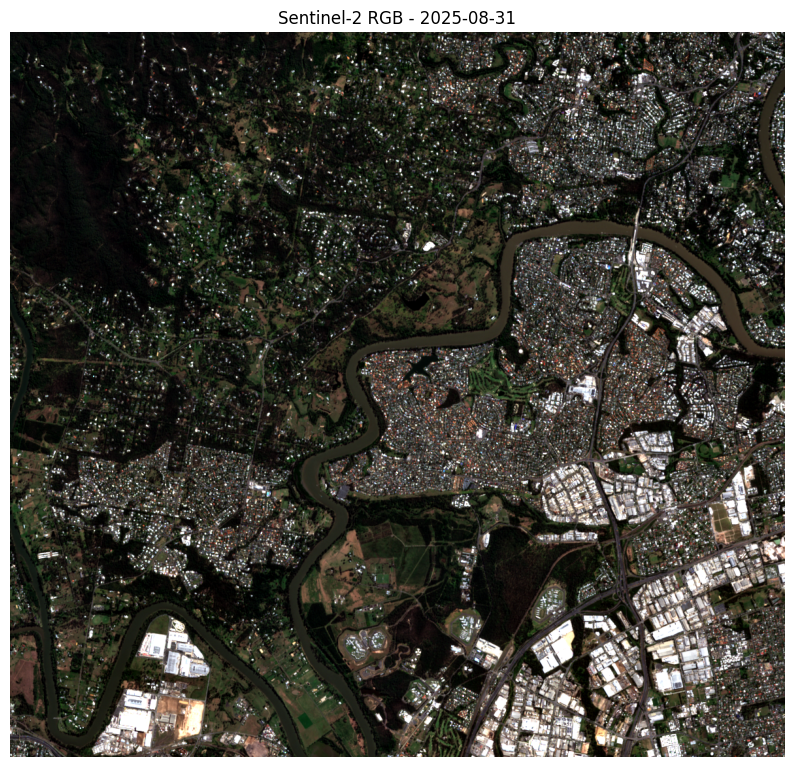

In [28]:
plt.figure(figsize=(10, 10))

plt.imshow(rgb)

plt.title(
    f"Sentinel-2 RGB - {item.datetime.date()}"
)

plt.axis("off")

plt.show()